In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Import Os and Basis Libraries
import cv2
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
#Matplot Images
import matplotlib.image as mpimg
# Tensflor and Keras Layer and Model and Optimize and Loss
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import *
from tensorflow.keras.losses import BinaryCrossentropy
#Kernel Intilizer
from sklearn.preprocessing import LabelEncoder
# import tensorflow_hub as hub
from tensorflow.keras.optimizers import Adam , Adamax
#PreTrained Model
from tensorflow.keras.applications import *
#Early Stopping
from tensorflow.keras.callbacks import EarlyStopping
# Warnings Remove
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Directory containing the "Train" folder
directory = "/content/drive/MyDrive/chest/train"

filepath =[]
label = []

folds = os.listdir(directory)

for fold in folds:
    f_path = os.path.join(directory , fold)

    imgs = os.listdir(f_path)

    for img in imgs:

        img_path = os.path.join(f_path , img)
        filepath.append(img_path)
        label.append(fold)

#Concat data paths with labels
file_path_series = pd.Series(filepath , name= 'filepath')
Label_path_series = pd.Series(label , name = 'label')
df_train = pd.concat([file_path_series ,Label_path_series ] , axis = 1)

In [ ]:
# Head
df_train

,filepath,label
0,/content/drive/MyDrive/chest/train/NORMAL/IM-0...,NORMAL
1,/content/drive/MyDrive/chest/train/NORMAL/IM-0...,NORMAL
2,/content/drive/MyDrive/chest/train/NORMAL/IM-0...,NORMAL
3,/content/drive/MyDrive/chest/train/NORMAL/IM-0...,NORMAL
4,/content/drive/MyDrive/chest/train/NORMAL/IM-0...,NORMAL
...,...,...
4563,/content/drive/MyDrive/chest/train/PNEUMONIA/p...,PNEUMONIA
4564,/content/drive/MyDrive/chest/train/PNEUMONIA/p...,PNEUMONIA
4565,/content/drive/MyDrive/chest/train/PNEUMONIA/p...,PNEUMONIA
4566,/content/drive/MyDrive/chest/train/PNEUMONIA/p...,PNEUMONIA


In [ ]:
# Directory containing the "Train" folder
directory = "/content/drive/MyDrive/chest/test"

filepath =[]
label = []

folds = os.listdir(directory)

for fold in folds:
    f_path = os.path.join(directory , fold)

    imgs = os.listdir(f_path)

    for img in imgs:

        img_path = os.path.join(f_path , img)
        filepath.append(img_path)
        label.append(fold)

#Concat data paths with labels
file_path_series = pd.Series(filepath , name= 'filepath')
Label_path_series = pd.Series(label , name = 'label')
df_test = pd.concat([file_path_series ,Label_path_series ] , axis = 1)

In [ ]:
# Head
df_test.sample(5)

,filepath,label
484,/content/drive/MyDrive/chest/test/NORMAL/NORMA...,NORMAL
403,/content/drive/MyDrive/chest/test/NORMAL/IM-00...,NORMAL
250,/content/drive/MyDrive/chest/test/PNEUMONIA/pe...,PNEUMONIA
360,/content/drive/MyDrive/chest/test/PNEUMONIA/pe...,PNEUMONIA
36,/content/drive/MyDrive/chest/test/PNEUMONIA/pe...,PNEUMONIA


In [ ]:
# Shape
print(f"The shape of The Train data is: {df_train.shape}")
print(f"The shape of The Test data is: {df_test.shape}")

The shape of The Train data is: (4568, 2)
The shape of The Test data is: (612, 2)


In [ ]:
#Data_Dir
data_dir = '/content/drive/MyDrive/chest/train'
test_dir = '/content/drive/MyDrive/chest/test'

IMAGE_SIZE = (256,256)

print('Training Images:')
# Creating the training dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.1,
    subset='training',
    seed=123,
    image_size=IMAGE_SIZE,
    batch_size=32)

#Testing  Data
print('Validation Images:')
validation_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.1,
    subset='validation',
    seed=123,
    image_size=IMAGE_SIZE,
    batch_size=32)

print('Testing Images:')
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    seed=123,
    image_size=IMAGE_SIZE,
    batch_size=32)

Training Images:
Found 4568 files belonging to 2 classes.
Using 4112 files for training.
Validation Images:
Found 4568 files belonging to 2 classes.
Using 456 files for validation.
Testing Images:
Found 612 files belonging to 2 classes.


In [ ]:
# Extract labels
train_labels = train_ds.class_names
test_labels = test_ds.class_names
validation_labels = validation_ds.class_names

# Encode Labels

# Define your class labels
class_labels = ['NORMAL', 'PNEUMONIA']

# Instantiate LabelEncoder
label_encoder = LabelEncoder()

# Fit label encoder on the class labels
label_encoder.fit(class_labels)

# Transform the labels for training dataset
train_labels_encoded = label_encoder.transform(train_labels)

# Transform the labels for validation dataset
validation_labels_encoded = label_encoder.transform(validation_labels)

# Transform the labels for test dataset
test_labels_encoded = label_encoder.transform(test_labels)

In [ ]:
# Shape of the dataset
for image_batch, labels_batch in train_ds:
    print("Shape of X_train: ", image_batch.shape)
    print("Shape of y_train: ", labels_batch.shape)
    break

Shape of X_train:  (32, 256, 256, 3)
Shape of y_train:  (32,)


In [ ]:
# Normalizing Pixel Values

# Train Data
train_ds = train_ds.map(lambda x, y: (x / 255.0, y))
# Val Data
validation_ds = validation_ds.map(lambda x, y: (x / 255.0, y))
# Test Data
test_ds = test_ds.map(lambda x, y: (x / 255.0, y))

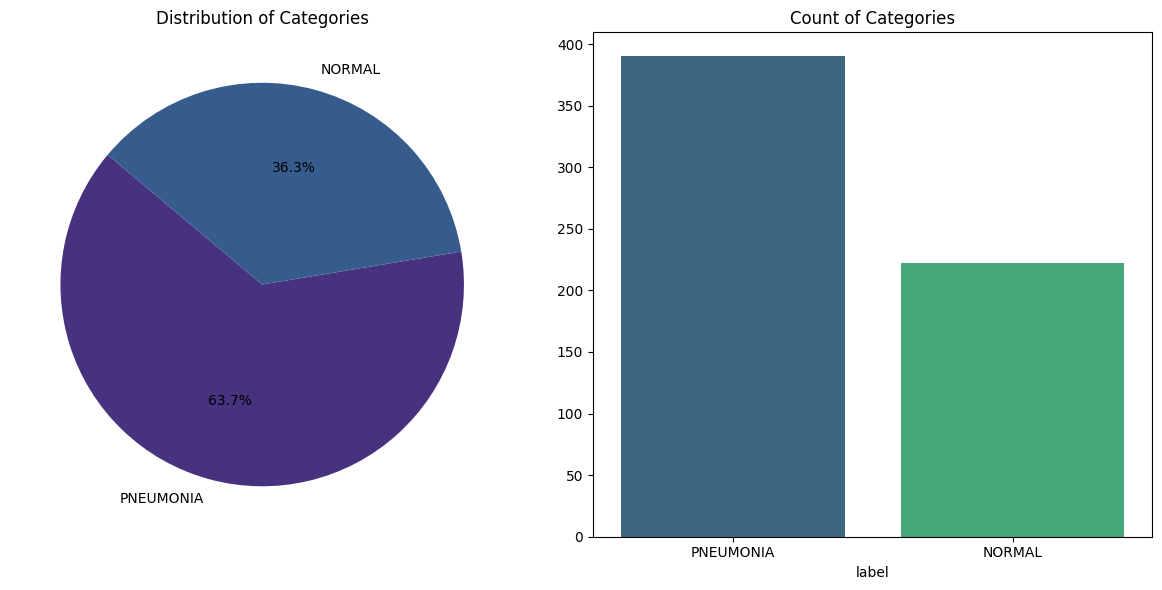

In [ ]:
# Count the occurrences of each category in the 'category' column
count = df_test['label'].value_counts()

# Create a figure with two subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6), facecolor='white')

# Plot pie chart on the first subplot
palette = sns.color_palette("viridis")
sns.set_palette(palette)
axs[0].pie(count, labels=count.index, autopct='%1.1f%%', startangle=140)
axs[0].set_title('Distribution of Categories')

# Plot bar chart on the second subplot
sns.barplot(x=count.index, y=count.values, ax=axs[1], palette="viridis")
axs[1].set_title('Count of Categories')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

In [ ]:
def visualize_images(path, num_images=5):
    # Get a list of image filenames in the specified path
    image_filenames = os.listdir(path)

    # Limit the number of images to visualize if there are more than num_images
    num_images = min(num_images, len(image_filenames))

    # Create a figure and axis object to display images
    fig, axes = plt.subplots(1, num_images, figsize=(15, 3),facecolor='white')

    # Iterate over the selected images and display them
    for i, image_filename in enumerate(image_filenames[:num_images]):
        # Load the image using Matplotlib
        image_path = os.path.join(path, image_filename)
        image = mpimg.imread(image_path)

        # Display the image
        axes[i].imshow(image)
        axes[i].axis('off')  # Turn off axis
        axes[i].set_title(image_filename)  # Set image filename as title

    # Adjust layout and display the figure
    plt.tight_layout()
    plt.show()

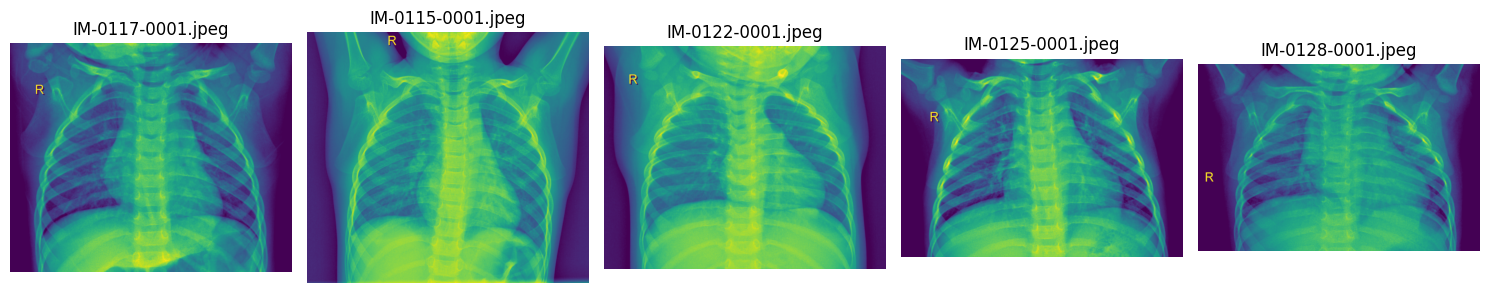

In [ ]:
# Specify the path containing the images to visualize
path_to_visualize = "/content/drive/MyDrive/chest/train/NORMAL"

# Visualize some images from the specified path
visualize_images(path_to_visualize, num_images=5)

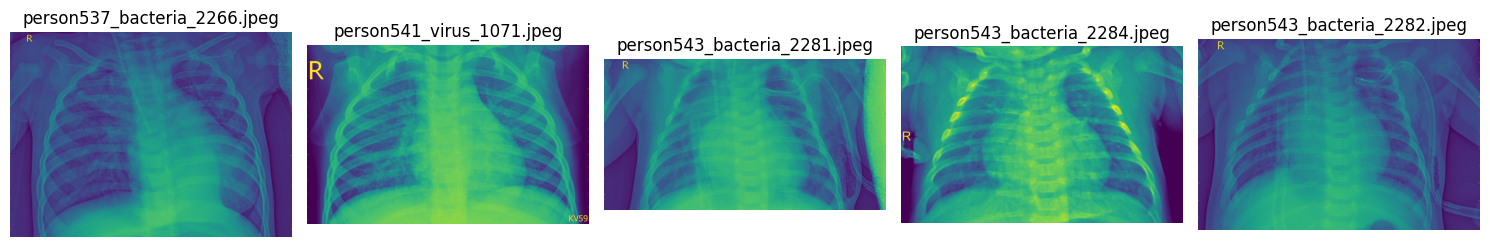

In [ ]:
# Specify the path containing the images to visualize
path_to_visualize = "/content/drive/MyDrive/chest/train/PNEUMONIA"

# Visualize some images from the specified path
visualize_images(path_to_visualize, num_images=5)

In [ ]:
# Load the Xception base model without the top (classification) layer
#base_model = Xception(weights='imagenet', include_top=False, pooling='avg', input_shape=(256, 256, 3))
#import efficientnet v2
#from tensorflow.keras.applications import EfficientNetV2S
#base_model = EfficientNetV2S(weights='imagenet', include_top=False, pooling='avg', input_shape=(256, 256, 3))
from tensorflow.keras.applications import EfficientNetV2M

base_model = EfficientNetV2M(
    weights='imagenet',        # Use pre-trained weights
    include_top=False,         # Remove the original final Dense layers
    pooling='avg',             # Global Average Pooling after conv layers
    input_shape=(256, 256, 3)  # Or (256, 256, 3) if you resized images
)

# Load the EfficientNetV2S base model without the top (classification) layer
#base_model = EfficientNetV2S(weights='imagenet', include_top=False, pooling='avg', input_shape=(256, 256, 3))
# Freeze the layers in the base model
base_model.trainable = False

# Build Model
model = Sequential()

# Base Model
model.add(base_model)

# Batch Normalization
model.add(BatchNormalization())

# Dropout Layer
model.add(Dropout(0.45))

# Dense Layer 1
model.add(Dense(220, activation='relu'))

# Dropout Layer
model.add(Dropout(0.25))

# Dense Layer 2
model.add(Dense(60,activation='relu'))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

# Compile
model.compile(optimizer=Adamax(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

214201816/214201816 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-m (Functional)   │ (None, 1280)           │    53,150,388 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 220)            │       281,820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 220)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 60)             │        13,260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            61 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,450,649 (203.90 MB)

 Trainable params: 297,701 (1.14 MB)

 Non-trainable params: 53,152,948 (202.76 MB)

###### **<h1 align="center"><span style="color:#6A5ACD;">Compile and Fitting</span>**

In [ ]:
#Early_Stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

#Fitting Model
history = model.fit(train_ds,
                        epochs= 30,
                        validation_data = validation_ds,
                        callbacks = early_stopping)

Epoch 1/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 235s 1s/step - accuracy: 0.8350 - loss: 0.4770 - val_accuracy: 0.8553 - val_loss: 0.6244
Epoch 2/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 11s 81ms/step - accuracy: 0.8455 - loss: 0.4001 - val_accuracy: 0.8684 - val_loss: 0.5566
Epoch 3/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 11s 82ms/step - accuracy: 0.8524 - loss: 0.3775 - val_accuracy: 0.8596 - val_loss: 0.4797
Epoch 4/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 11s 82ms/step - accuracy: 0.8482 - loss: 0.3805 - val_accuracy: 0.8465 - val_loss: 0.3963
Epoch 5/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 11s 82ms/step - accuracy: 0.8531 - loss: 0.3637 - val_accuracy: 0.8421 - val_loss: 0.3633
Epoch 6/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 11s 82ms/step - accuracy: 0.8468 - loss: 0.3655 - val_accuracy: 0.8399 - val_loss: 0.3422
Epoch 7/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 11s 82ms/step - accuracy: 0.8464 - loss: 0.3589 - val_accuracy: 0.8377 - val_loss: 0.3146
Epoch 8/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 10s 79ms/step - accuracy: 0.8510 - loss: 0.3631 - v

In [ ]:
model.save('/content/drive/MyDrive/chest/efficientnetv2m_final_model.keras')

In [ ]:
# Evaluate the model on the validation dataset
validation_loss, validation_accuracy = model.evaluate(validation_ds)

# Print the validation loss and accuracy
print("Validation Loss:", validation_loss)
print("Validation Accuracy:", validation_accuracy)

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.8708 - loss: 0.2542
Validation Loss: 0.2600513696670532
Validation Accuracy: 0.8662280440330505


In [ ]:
 from tensorflow.keras.models import load_model


In [ ]:
mymodel=load_model('/content/drive/MyDrive/chest/efficientnetv2m_final_model.keras')

In [ ]:
# Evaluate the model on the validation dataset
validation_loss, validation_accuracy = mymodel.evaluate(validation_ds)

# Print the validation loss and accuracy
print("Validation Loss:", validation_loss)
print("Validation Accuracy:", validation_accuracy)

15/15 ━━━━━━━━━━━━━━━━━━━━ 26s 450ms/step - accuracy: 0.8557 - loss: 0.2409
Validation Loss: 0.2599674463272095
Validation Accuracy: 0.8662280440330505


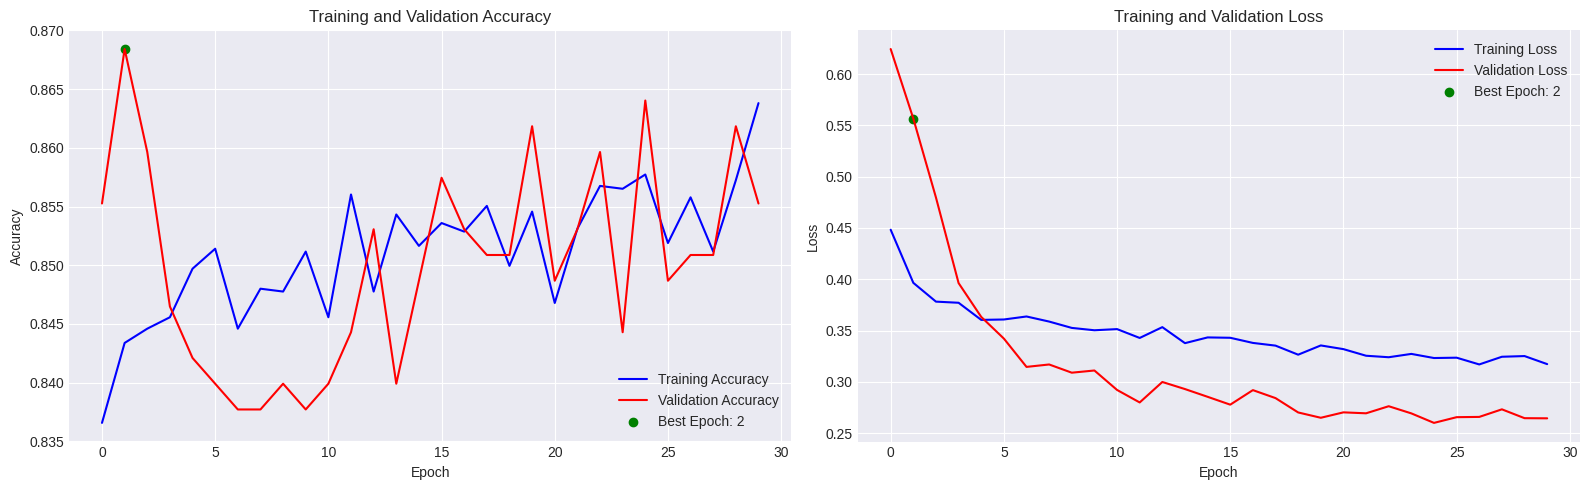

In [ ]:
# Get the epoch with the highest validation accuracy
best_epoch = history.history['val_accuracy'].index(max(history.history['val_accuracy'])) + 1

# Set the background style
#plt.style.use('seaborn-darkgrid') # This line is causing the error
plt.style.use('seaborn-v0_8-darkgrid') # Use this line instead


# Create a subplot with 1 row and 2 columns
fig, axs = plt.subplots(1, 2, figsize=(16, 5))

# Plot training and validation accuracy
axs[0].plot(history.history['accuracy'], label='Training Accuracy', color='blue')
axs[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
axs[0].scatter(best_epoch - 1, history.history['val_accuracy'][best_epoch - 1], color='green', label=f'Best Epoch: {best_epoch}')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Accuracy')
axs[0].set_title('Training and Validation Accuracy')
axs[0].legend()

# Plot training and validation loss
axs[1].plot(history.history['loss'], label='Training Loss', color='blue')
axs[1].plot(history.history['val_loss'], label='Validation Loss', color='red')
axs[1].scatter(best_epoch - 1, history.history['val_loss'][best_epoch - 1], color='green',label=f'Best Epoch: {best_epoch}')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Loss')
axs[1].set_title('Training and Validation Loss')
axs[1].legend()

plt.tight_layout()
plt.show()

Testing Images:
Found 612 files belonging to 2 classes.
Testing Images:
20/20 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step


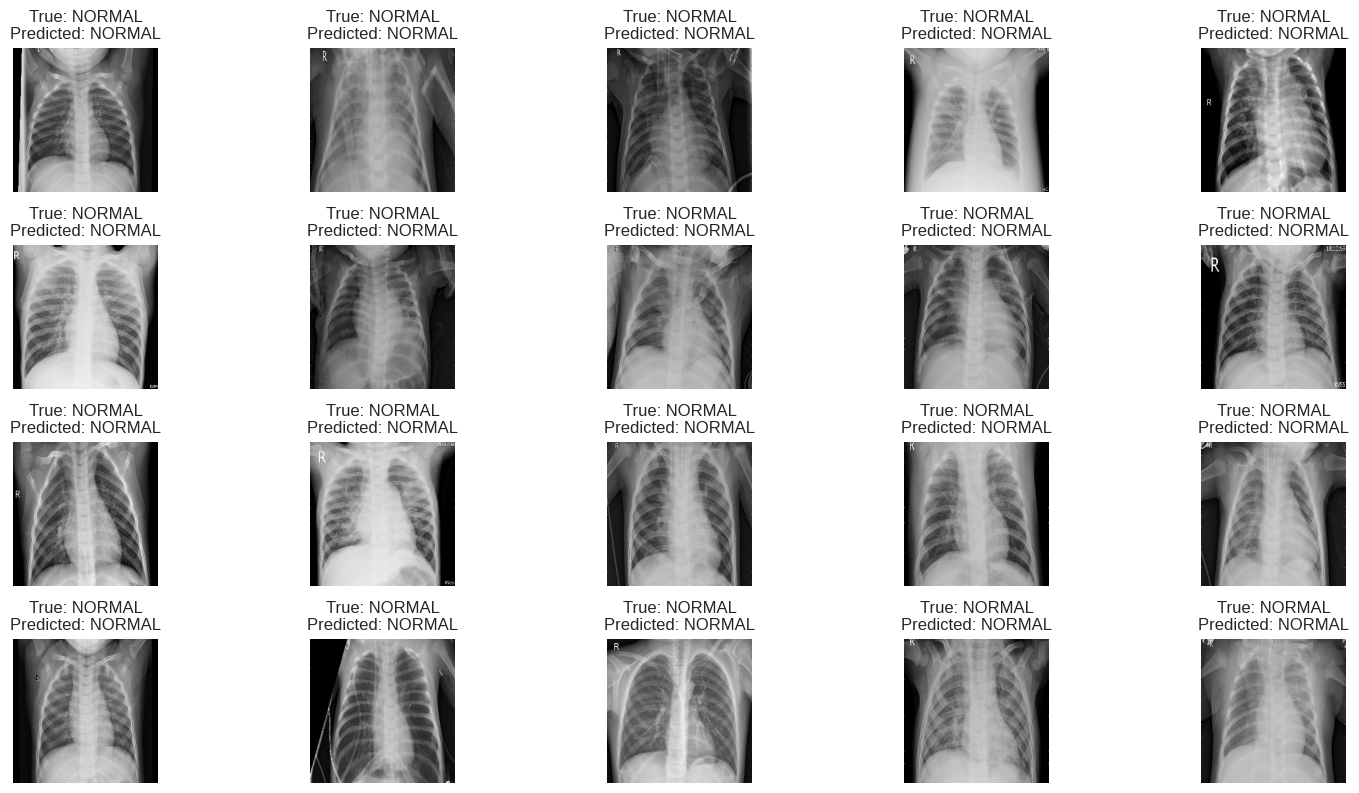

In [ ]:
test_dir = '/content/drive/MyDrive/chest/test'
print('Testing Images:')
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    seed=123,
    image_size=IMAGE_SIZE,
    batch_size=32)

# Define a function to plot images with their true and predicted labels
def plot_images_with_predictions(model, dataset, class_labels, num_images=40, num_images_per_row=5):
    # Generate predictions for a set number of images
    predictions = model.predict(dataset)

    # Shuffle the dataset
    dataset_shuffled = dataset.shuffle(buffer_size=len(dataset))

    plt.figure(figsize=(15, 10))
    for i, (images, labels) in enumerate(dataset_shuffled.take(num_images)):
        # Convert tensor to NumPy array
        images = images.numpy()

        # Iterate over each image in the batch
        for j in range(len(images)):
            if i * num_images_per_row + j < num_images:  # Check if the total number of images exceeds the desired count
                predicted_class = class_labels[np.argmax(predictions[i * num_images_per_row + j])]
                true_class = class_labels[np.argmax(labels[j])]

                plt.subplot(num_images // num_images_per_row + 1, num_images_per_row, i * num_images_per_row + j + 1)
                plt.imshow(images[j].astype("uint8"))
                plt.title(f'True: {true_class}\nPredicted: {predicted_class}')
                plt.axis('off')

    plt.tight_layout()
    plt.show()

# Visualize predictions on random 20 images from the testing dataset
print('Testing Images:')
plot_images_with_predictions(model, test_ds, class_labels, num_images=20)

1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


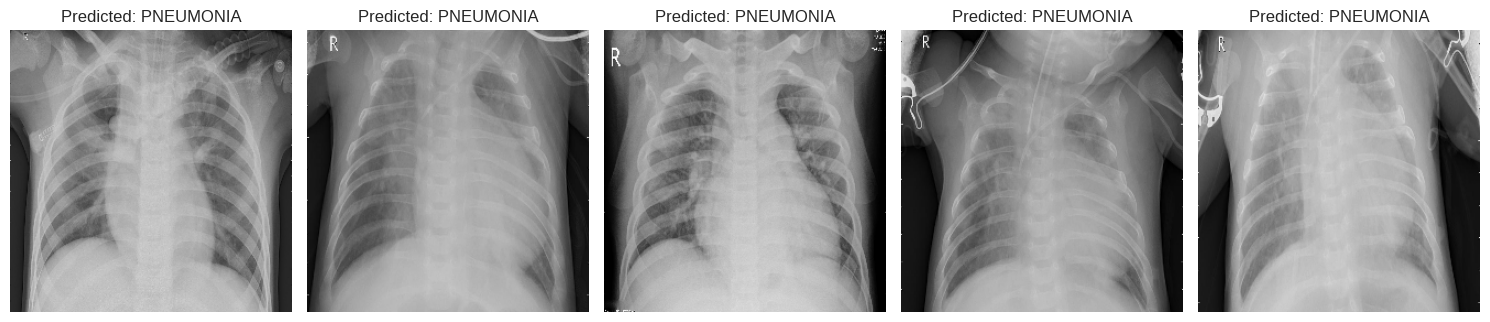

In [ ]:
# Path to the directory containing the images
directory_path = '/content/drive/MyDrive/chest/test/PNEUMONIA'

# Select N image files from the directory
image_files = os.listdir(directory_path)[:5]

# Create a figure and axes for subplots
fig, axs = plt.subplots(1, len(image_files), figsize=(15, 5))

# Load and preprocess each image, make predictions, and display them using a loop
for i, image_file in enumerate(image_files):
    img_path = os.path.join(directory_path, image_file)
    # Load the image using OpenCV
    img = cv2.imread(img_path)
    # Resize the image to (256, 256)
    img = cv2.resize(img, (256, 256))

    # Normalize pixel values
    img_array = img.astype(np.float32) / 255.0

    # Expand the dimensions to match the input shape expected by the model
    img_array = np.expand_dims(img_array, axis=0)

    # Make predictions
    predictions = model.predict(img_array)
    actual_prediction = (predictions > 0.5).astype(int)

    # Display the image with predicted label
    # Convert BGR to RGB for displaying with matplotlib
    axs[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axs[i].axis('off')
    if actual_prediction[0][0] == 0:
        predicted_label = 'Normal'
    else:
        predicted_label = 'PNEUMONIA'
    axs[i].set_title(f'Predicted: {predicted_label}')

# Adjust layout
plt.tight_layout()
plt.show()